Current working directory: c:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding
Data path: C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding
Figure path: c:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\figures
Results path: c:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\results
Model path: c:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\models
Processing image 3922_20_1_01232020_80_wrp.tiff


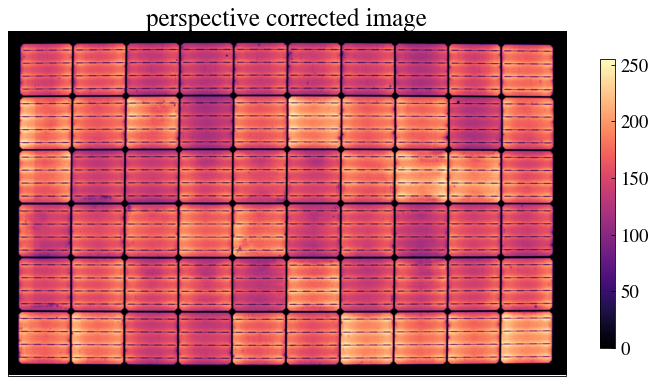

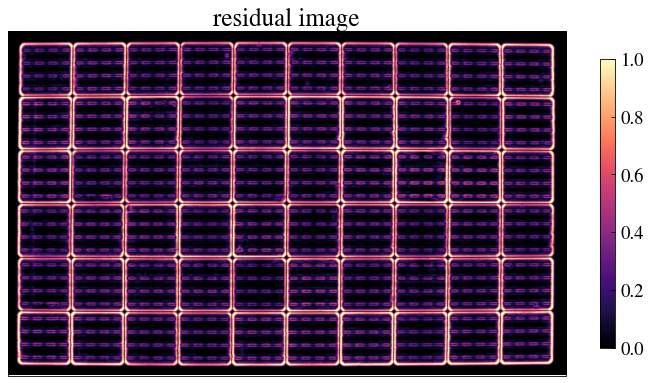

621.2564321171293 2442.8960226426702


c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



 cluster centres
[ 119.5         655.625      1206.75       1762.65714286 2320.28571429
 2877.         3434.37837838 3989.02857143 4542.         5089.35135135
 5619.5       ]
Median spacing: 553.81
Edge gap (left): 119.50, Edge gap (right): -2059.50
No significant spacing anomalies detected (range < 10% of median).
1487.1027697151073 3944.754642261749

 cluster centres
[ 141.5         682.85714286 1232.1        1788.80645161 2346.56666667
 2905.8125     3445.        ]
Median spacing: 552.97
Edge gap (left): 141.50, Edge gap (right): 2325.00
No significant spacing anomalies detected (range < 10% of median).


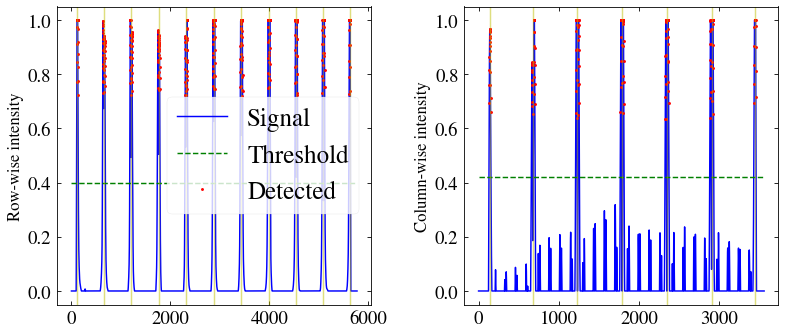

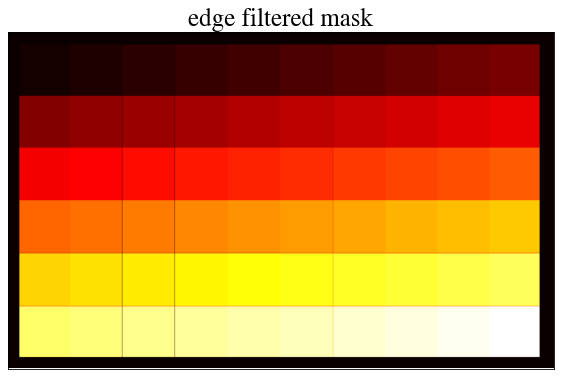

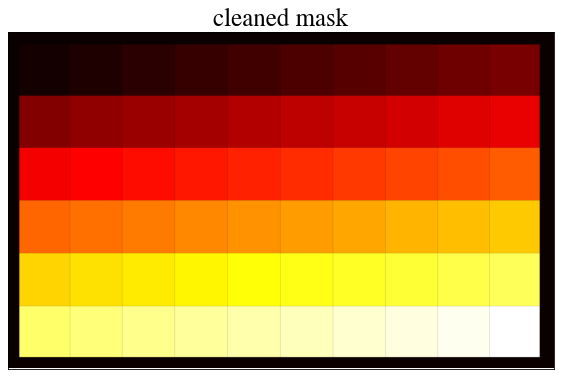

median aspect ratio:  1.0018018018018018


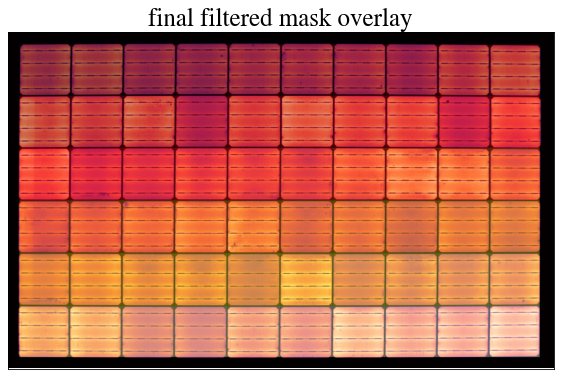

shape  [557 556]
cells shape:  (60, 557, 556)
shape  [557 556]
cells shape:  (60, 557, 556)


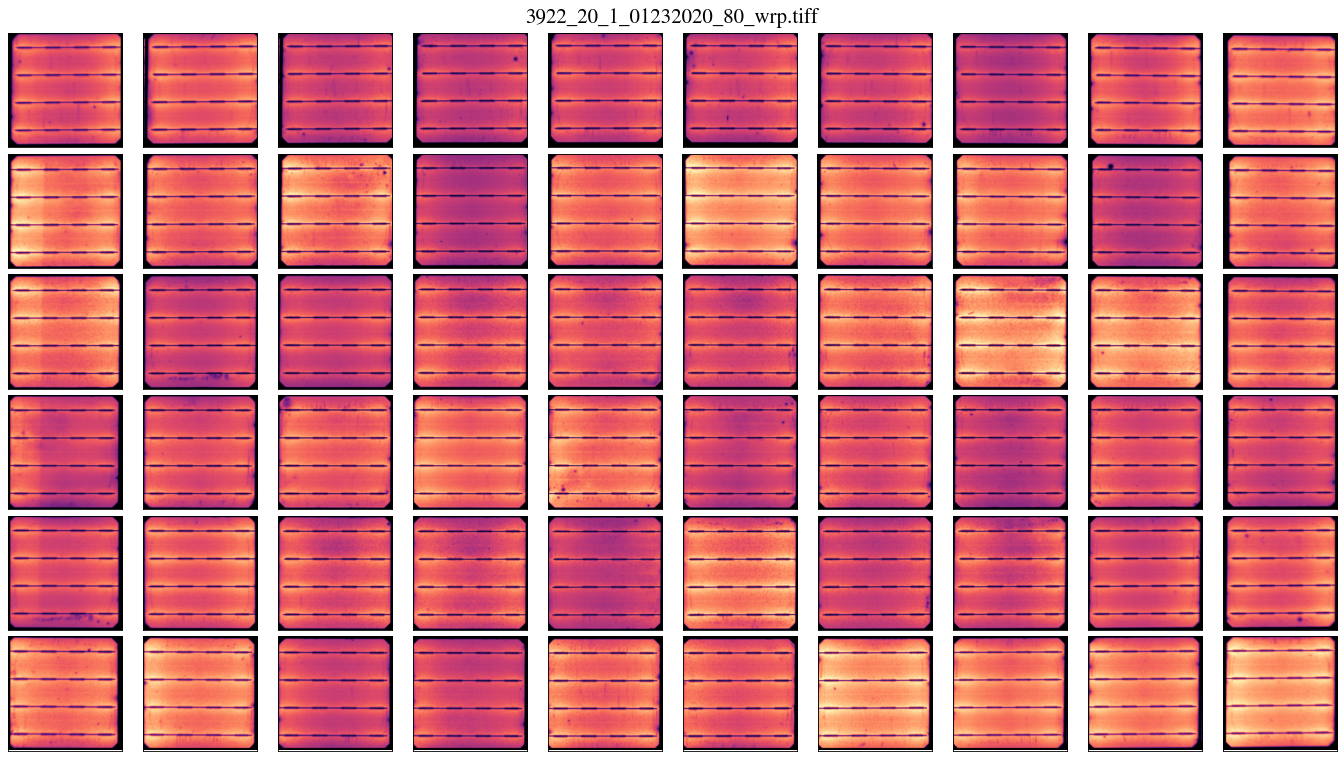

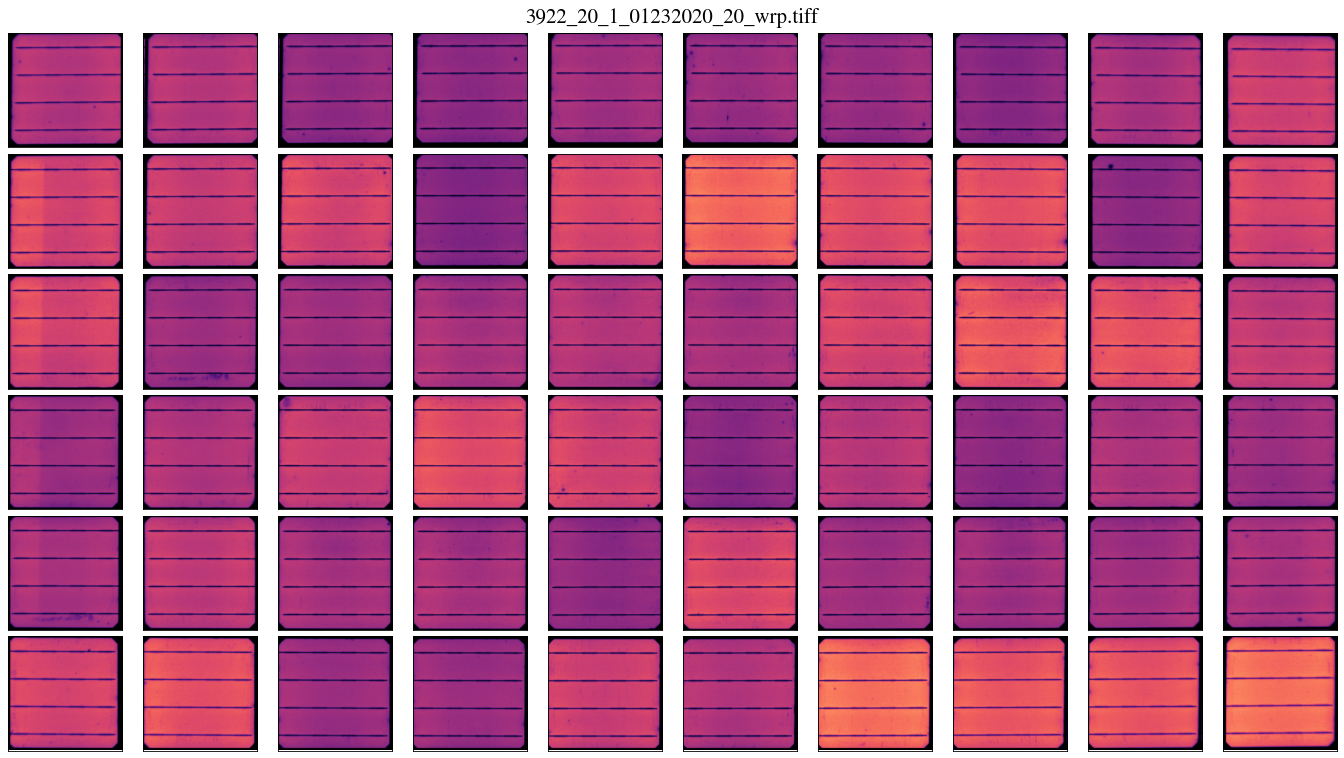

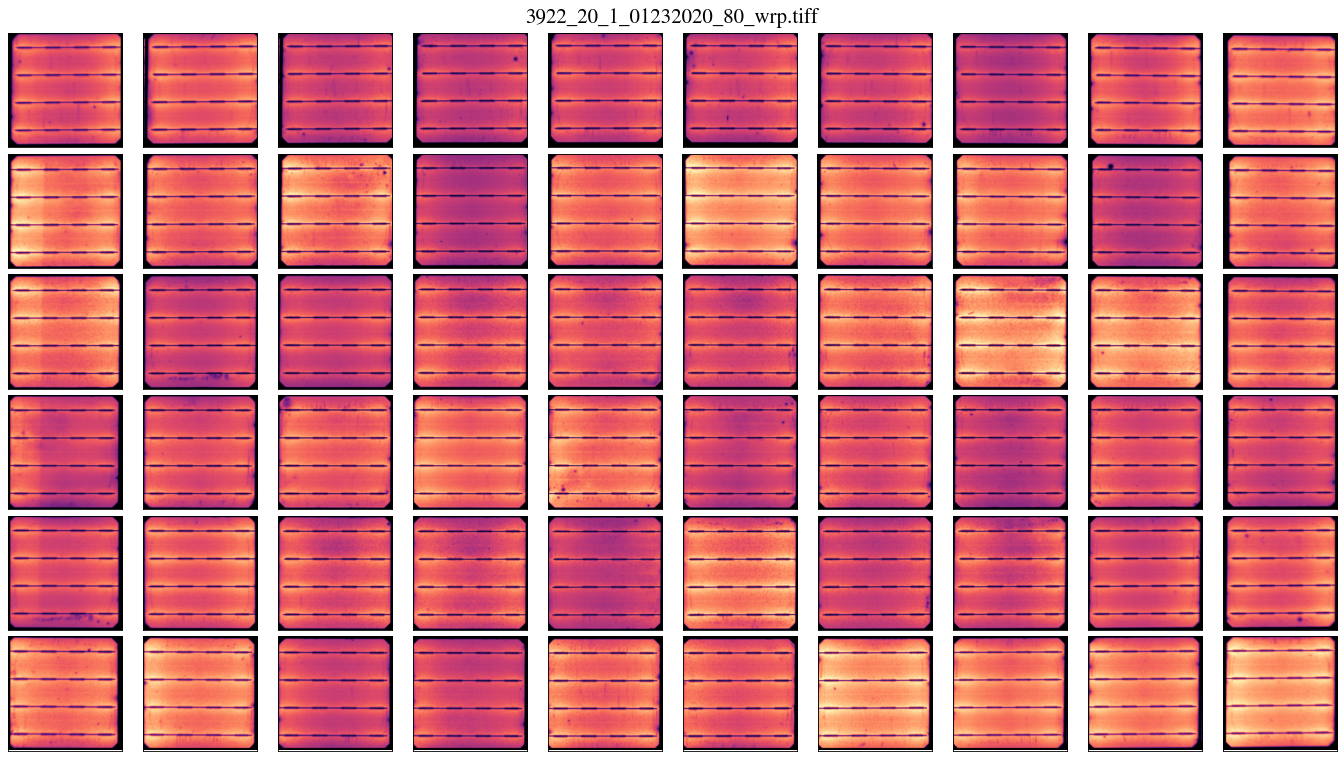

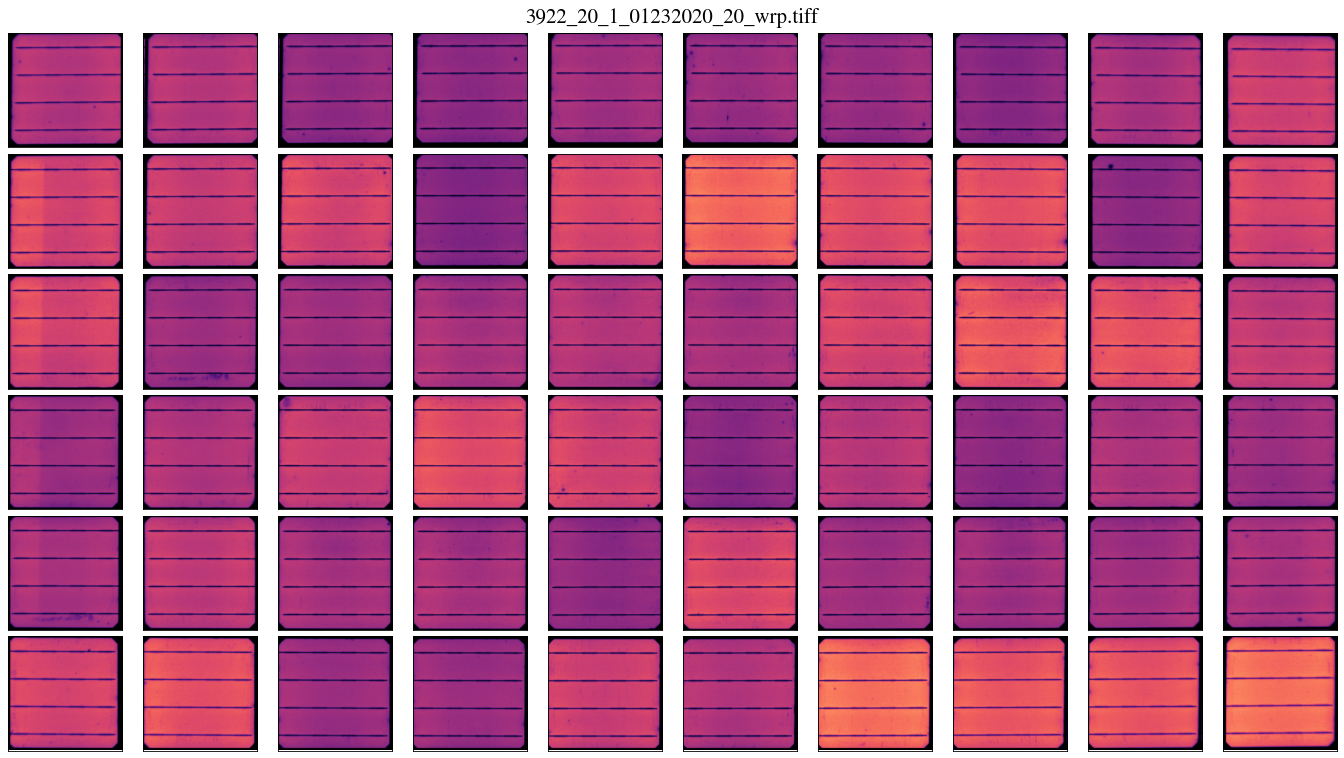

In [6]:
# %% -- import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import re
import scipy
import skimage
import datetime
from sklearn.cluster import KMeans
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize

cwd = os.getcwd()
print('Current working directory:', cwd)

# add relevant dirs too
# data dir
#data_dir = os.path.abspath(os.path.join(cwd, '..', 'data'))
data_dir = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding"
print('Data path:', data_dir)

# figure dir
fig_dir = os.path.abspath(os.path.join(cwd, '..', 'figures'))
print('Figure path:', fig_dir)

# results dir
results_dir = os.path.abspath(os.path.join(cwd, '..', 'results'))
print('Results path:', results_dir)

# model dir
model_dir = os.path.abspath(os.path.join(cwd, '..', 'models'))
print('Model path:', model_dir)

# %% -- support functions
# Matplotlib stylesheet
import matplotlib as mpl

mpl.style.use('seaborn-v0_8-paper')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] ='STIXGeneral'
mpl.rcParams['mathtext.default'] = 'rm'
mpl.rcParams['mathtext.fallback'] = 'cm'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 24
mpl.rcParams['axes.labelsize'] = 24
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['axes.labelweight'] = 'normal'
mpl.rcParams['axes.xmargin']=0.05
mpl.rcParams['axes.ymargin']=0.05
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['legend.fontsize'] = 24
mpl.rcParams['legend.title_fontsize'] = 24
mpl.rcParams['figure.titlesize'] = 24
# mpl.rcParams['figure.figsize'] = (16.18,10)
# mpl.rcParams['figure.figsize'] = (16.18,12)
mpl.rcParams['figure.figsize'] = (12,10)
mpl.rcParams['figure.autolayout'] = False
mpl.rcParams['figure.dpi'] = 75
mpl.rcParams['savefig.dpi'] = 150
mpl.rcParams['errorbar.capsize'] = 3


# Pickle functions
import pickle

def SaveObj(obj, folder, name):
    if '.pkl' in name:
        with open(os.path.join(folder,name), 'rb') as f:
            pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)
    else:
        with open(os.path.join(folder,name) + '.pkl', 'wb') as f:
            pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

def LoadObj(folder, name):
    if '.pkl' in name:
        with open(os.path.join(folder,name), 'rb') as f:
            return pickle.load(f)
    else:
        with open(os.path.join(folder,name)+ '.pkl', 'rb') as f:
            return pickle.load(f)

# quick plot of an image
def quick_plot(img, title=None, cmap="inferno", cbar=False):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.xticks([]) 
    plt.yticks([])

    if cbar:
        plt.colorbar(shrink=0.5)
    
    plt.show()
    return

# %% -- generate grid mask functions

def adjust_cluster_centres(centres, slen, pad=10, tolerance=0.05, plot=False, max_iter=5):
    """
    Iteratively move outlier centre(s) from too-close pairs into large gaps.
    After each single move the distances and median are recalculated so cases
    where two centres are incorrect (or multiple corrections needed) are handled.
    
    Also checks for missing cluster centres at the edges using slen (axis length).
    If the gap from 0 to first centre or from last centre to slen is significantly
    larger than the median spacing, a missing centre may be added.
    """
    centres = np.asarray(np.sort(centres), dtype=float)
    n = len(centres)
    if n < 3:
        return centres
    
    # Compute distances between consecutive centres
    distances = np.diff(centres)
    # Compute median distance (robust to outliers)
    median_dist = np.median(distances)
    
    # Check for missing cluster centres at the edges using slen
    edge_gap_left = centres[0] - 0  # gap from start to first centre
    edge_gap_right = slen - centres[-1]  # gap from last centre to end
    
    print(f"Median spacing: {median_dist:.2f}")
    print(f"Edge gap (left): {edge_gap_left:.2f}, Edge gap (right): {edge_gap_right:.2f}")
    
    # If edge gaps are significantly larger than median spacing, might be missing centre
    if edge_gap_left > median_dist * (1 + tolerance):
        print(f"WARNING: Large gap at left edge ({edge_gap_left:.2f} > {median_dist * (1 + tolerance):.2f}). Possible missing cluster centre.")
        # check distance between first and second centre to determine candidate position (prefer median spacing from first centre, fallback to pad)
        if (centres[1] - centres[0]) < median_dist * (1 + tolerance):
            edge_left_candidate = centres[0] - median_dist
        else:
            edge_left_candidate = pad
    else:
        edge_left_candidate = None

    if edge_gap_right > median_dist * (1 + tolerance):
        print(f"WARNING: Large gap at right edge ({edge_gap_right:.2f} > {median_dist * (1 + tolerance):.2f}). Possible missing cluster centre.")
        # check distance between last and second-last centre to determine candidate position (prefer median spacing from last centre, fallback to slen - pad)
        if (centres[-1] - centres[-2]) < median_dist * (1 + tolerance):
            edge_right_candidate = centres[-1] + median_dist
        else:
            edge_right_candidate = slen - pad
    else:
        edge_right_candidate = None
        
    # Identify which distances deviate from median beyond tolerance (smaller only)
    outlier_idx = np.where(distances < median_dist * (1 - tolerance))[0]
    # Check if there are significant outliers by examining distance range
    min_dist = np.min(distances)
    max_dist = np.max(distances)
    dist_range = max_dist - min_dist
    range_pct = dist_range / median_dist
    # Only proceed if range is significant (>10% of median) AND outliers exist
    if range_pct < 0.10:
        print("No significant spacing anomalies detected (range < 10% of median).")
        return centres
    if len(outlier_idx) == 0:
        print("No spacing anomalies detected (all deviations within tolerance).")
        return centres
    if len(outlier_idx) > 2:
        print("WARNING: More than 2 anomalies detected. Adjustment may not be reliable.")
        print("Returning original centres.")
        return centres

    adjusted = centres.copy()
    for it in range(max_iter):
        distances = np.diff(adjusted)
        median_dist = np.median(distances)

        # find too-close and too-large gaps
        small_idx = np.where(distances < median_dist * (1 - tolerance))[0]
        large_idx = np.where(distances > median_dist * (1 + tolerance))[0]

        # nothing to fix
        if small_idx.size == 0:
            break

        moved = False

        # build candidate positions for large gaps (prefer left + median, fallback midpoint)
        candidates = []
        if edge_left_candidate is not None:
            candidates.append(edge_left_candidate)
        if edge_right_candidate is not None:
            candidates.append(edge_right_candidate)
        # print(large_idx)
        for j in large_idx[::2]:
            left = adjusted[j]
            right = adjusted[j + 1]
            pref = left + median_dist
            mid = 0.5 * (left + right)
            candidates.append(pref)
            candidates.append(mid)
        # print(candidates)
        # Try to fix each small gap, but recompute after a single successful move
        for s in small_idx:
            best_move = np.inf
            best_candidate = None
            best_move_idx = None
            for cand in candidates:
                # try moving left or right member of small pair
                move_left = abs(adjusted[s] - cand)
                move_right = abs(adjusted[s + 1] + cand)
                if (move_left < best_move) and (move_left > centres[0] - median_dist * 1.25): # sanity check; don't move too far left
                    best_move = move_left; best_candidate = cand; best_move_idx = s
                if (move_right < best_move) and (move_right > centres[-1] + median_dist * 1.25): # sanity check; don't move too far right
                    best_move = move_right; best_candidate = cand; best_move_idx = s + 1
            print(f"Best move for small gap at index {s} is to move index {best_move_idx} to {best_candidate})")
            if best_candidate is None:
                print("No valid candidate found for adjustment.")
                continue

            # sanity: candidate should not collide with neighbours
            others = np.delete(adjusted, best_move_idx)
            if others.size == 0:
                d_to_nearest = np.inf
            else:
                d_to_nearest = np.min(np.abs(others - best_candidate))

            if d_to_nearest > median_dist * 0.25:
                # print(best_candidate, d_to_nearest)
                adjusted[best_move_idx] = best_candidate
                adjusted = np.sort(adjusted)
                moved = True
                # recompute distances/median in next iteration (handles multiple bad points)
                break

        # If no large-gap candidate was available or no safe move, fallback:
        if not moved and small_idx.size:
            print("Fallback adjustment for small gaps.")
            # move right member of each small pair to left + median if safe (without shifting others)
            for s in small_idx:
                cand = adjusted[s] + median_dist
                others = np.delete(adjusted, s + 1)
                d_to_nearest = np.min(np.abs(others - cand)) if others.size else np.inf
                if d_to_nearest > median_dist * 0.25:
                    adjusted[s + 1] = cand
                    adjusted = np.sort(adjusted)
                    moved = True
                    break

        # if nothing moved this iteration, stop to avoid infinite loop
        if not moved:
            break

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
        ax1.scatter(centres, np.ones_like(centres), s=80); ax1.set_title("Original")
        ax2.scatter(adjusted, np.ones_like(adjusted), s=80, color='orange'); ax2.set_title("Adjusted")
        ax1.set_xlim(0, slen)
        ax2.set_xlim(0, slen)
        for i, c in enumerate(centres): ax1.text(c, 1.01, f"{i}", ha='center', fontsize=12)
        for i, c in enumerate(adjusted): ax2.text(c, 1.01, f"{i}", ha='center', fontsize=12)
        plt.tight_layout(); plt.show(); plt.close()

    return adjusted

def grid_mask_from_median_peak(res, wrp, params, plot=False):
    """
    Create grid mask by clustering detected edge points and using median values
    
    Parameters:
    res: ndarray - gradient/residual image
    wrp: ndarray - original warped image
    params: dict - parameters for processing
    rows: int - number of cell rows
    cols: int - number of cell columns
    plot: bool - whether to show visualization
    """
    if plot:
        _w = 11; _h = 5
        fig = plt.figure(figsize=(_w, _h))
        ax = []
        ax.append(fig.add_subplot(121))
        ax.append(fig.add_subplot(122))

    # Select axis aggregation function
    _f = np.sum if params["aggregation_func"] == "sum" else np.median
    
    # Store detected edge points for each axis
    _ax_pts = []
    
    # Iterate each axis (0=rows, 1=columns)
    for _axx in [0, 1]:
        # Compute axis aggregate
        _x_s = _f(res, axis=_axx)

        # apply histogram equilisation to the axis aggregate
        p2, p98 = np.percentile(_x_s, (75, 98))
        print(p2, p98)
        _x_s = skimage.exposure.rescale_intensity(_x_s, in_range=(p2, p98))
        
        # Compute threshold
        _val = skimage.filters.threshold_otsu(_x_s)
        
        # Get points above threshold
        if _axx == 1:
            _ = np.where(_x_s > _val * params["axs1_otsu_scale"])[0]
        else:
            _ = np.where(_x_s > _val * params["axs0_otsu_scale"])[0]
        
        # Store detected points
        points = _[::-1]  # Reverse order to match image coordinates
        
        # Determine number of clusters needed
        cols = params["cols"]
        rows = params["rows"]
        n_clusters = rows + 1 if _axx == 1 else cols + 1
        
        # Reshape points for clustering
        X = points.reshape(-1, 1)
        
        # Perform k-means clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(X)
        
        # Get cluster centers and sort them
        cluster_centers = np.sort(kmeans.cluster_centers_.flatten())
        print("\n cluster centres")
        print(cluster_centers)

        cluster_centers = adjust_cluster_centres(cluster_centers, slen=res.shape[_axx], pad=params.get('padding', 10), tolerance=0.1, plot=True)
        
        # Store cluster centers as edge points
        _ax_pts.append(cluster_centers.astype(int))
        
        if plot:
            # Plot original signal
            ax[_axx].plot(_x_s, '-b', label='Signal')
            ax[_axx].plot([0, _x_s.shape[0]], [_val, _val], '--g', label='Threshold')
            
            # Plot detected points
            ax[_axx].plot(points, _x_s[points], '.r', label='Detected')
            
            # Plot cluster centers
            for center in cluster_centers:
                ax[_axx].axvline(x=center, color='y', alpha=0.5)
        
            # ax[_axx].legend()

    if plot:
        ax[0].set_ylabel('Row-wise intensity', fontsize=16)
        ax[1].set_ylabel('Column-wise intensity', fontsize=16)
        ax[0].legend()
        plt.tight_layout()
        plt.show()
        plt.close()

    # Build grid mask using cluster centers
    gmask = np.zeros(wrp.shape)
    for i, centers in enumerate(_ax_pts):
        for center in centers:
            if i == 0:  # Row lines
                gmask[:, center] = 1
            elif i == 1:  # Column lines
                gmask[center, :] = 1

    return gmask

def minmax_scale_image(image_array):
    """
    Applies Min-Max scaling to an image represented as a NumPy array.
    Scales pixel values to the range [0, 1].
    """
    min_intensity = np.min(image_array)
    max_intensity = np.max(image_array)

    # Avoid division by zero if all pixels have the same value
    if max_intensity == min_intensity:
        return np.zeros_like(image_array, dtype=float)

    scaled_image = (image_array - min_intensity) / (max_intensity - min_intensity) * 255
    return scaled_image

# %% -- clean mask functions
def generate_new_mask(lmask, lbls):
    # generate blank mask
    new_lmask = np.zeros(lmask.shape)
    # iterate over points, skip background
    for i, l in enumerate(lbls):
        # get points from label
        _idx = np.where(lmask == l)
        # generate isolated mask for single label point
        new_lmask[_idx] = l

    return new_lmask

def edge_feature_filter(lmask, tight_filter=True, plot=False):   
    '''filter edge masks'''
    # find edge area adjacent labels
    _edga = []
    # define edge adjacent range (pxls)
    _er = 2
    # for each edge, get edge adjacent area labels, drop first (zero)
    [ _edga.append(_) for _ in np.unique(lmask[:,:_er])[1:] ]
    [ _edga.append(_) for _ in np.unique(lmask[:,-_er:])[1:] ]
    [ _edga.append(_) for _ in np.unique(lmask[:_er,:])[1:] ]
    [ _edga.append(_) for _ in np.unique(lmask[-_er:,:])[1:] ]
    _edga = np.array(_edga, dtype = np.int32)

    # iterate area labels
    for _e in _edga:
        # set area to background (zero)
        lmask[np.where(lmask == _e)] = 0

    # relabel mask
    lmask = skimage.measure.label(lmask, background = 1)

    if plot:
        ''' display filtered mask '''
        _w = 8; _h = 6; fig = plt.figure(figsize = (_w, _h))
        ax = []; ax.append(fig.add_subplot(111))
        ax[0].set_xticks([]); ax[0].set_yticks([])
        ax[0].imshow(cv2.resize(lmask.astype(np.float64), (int(lmask.shape[1]/4), int(lmask.shape[0]/4)), cv2.INTER_AREA), cmap = 'hot', alpha = 1.)
        ax[0].set_title('edge filtered mask')
        plt.tight_layout()
        plt.show()
        plt.close()

    return lmask

def clean_wrp(wrp, plot=False):
    _x_s = np.sum(wrp, axis=1)

    # identify the background region
    _otsu = skimage.filters.threshold_otsu(_x_s)

    _extra = 10

    # get top and bottom indices
    _idx_top = np.where(_x_s > _otsu)[0][0] - _extra
    if _idx_top < 0:
        _idx_top = 0

    _idx_bot = np.where(_x_s > _otsu)[0][-1] + _extra
    if _idx_bot > wrp.shape[0]:
        _idx_bot = wrp.shape[0]
    print("Extracting rows {} to {}".format(_idx_top, _idx_bot))

    return wrp[_idx_top:_idx_bot, :]

def median_pxl_filter(lmask, tight_filter=True, plot=False):
    '''apply median pxl size filter'''
    # get sorted list unique labels for points
    lbls = np.unique(lmask)
    pxls = []
    # iterate over points, skip background
    for i, l in enumerate(lbls[:]):
        # get points from label
        _idx = np.where(lmask == l)
        pxls.append( _idx[0].shape[0] )
    ## perform filtering by stats of point pixel counts
    print("median pixel size: ",np.median(pxls))
    if tight_filter:
        med_filtered_lbls = [ l for i, l in enumerate(lbls) if
                (pxls[i] > .75*np.median(pxls)) and (pxls[i] < 1.5*np.median(pxls)) ]
    else:
        med_filtered_lbls = [ l for i, l in enumerate(lbls) if
                (pxls[i] > .5*np.median(pxls)) and (pxls[i] < 2.*np.median(pxls)) ]
    
    # generate new lmask
    med_filtered_lmask = generate_new_mask(lmask=lmask, lbls=med_filtered_lbls)
    

    if plot:
        ''' display filtered mask '''
        _w = 8; _h = 6; fig = plt.figure(figsize = (_w, _h))
        ax = []; ax.append(fig.add_subplot(111))
        ax[0].set_xticks([]); ax[0].set_yticks([])
        ax[0].imshow(cv2.resize(med_filtered_lmask.astype(np.float64), (int(med_filtered_lmask.shape[1]/4), int(med_filtered_lmask.shape[0]/4)), cv2.INTER_AREA), cmap = 'hot', alpha = 1.)
        ax[0].set_title('median filtered mask')
        plt.tight_layout()
        plt.show()
        plt.close()

    return med_filtered_lmask

def aspect_ratio_filter(lmask, tight_filter=True, plot=False):
    '''apply aspect ratio filter '''
    lbls = np.unique(lmask)
    pxls = []
    # iterate over points, skip background
    for i, l in enumerate(lbls[:]):
        # get points from label
        _idx = np.where(lmask == l)
        ## compute aspect ratio
        _aspt = np.ptp(_idx[0]) / np.ptp(_idx[1])
        pxls.append( _aspt )

    ## perform filtering by stats of point pixel counts
    print("median aspect ratio: ",np.median(pxls))
    if tight_filter:
        asp_filtered_lbls = [ l for i, l in enumerate(lbls[:]) if
                (pxls[i] > .75*np.median(pxls)) and (pxls[i] < 1.2*np.median(pxls)) ]
    else:
        asp_filtered_lbls = [ l for i, l in enumerate(lbls[:]) if
                (pxls[i] > .5*np.median(pxls)) and (pxls[i] < 2.*np.median(pxls)) ]
        
    # generate new lmask
    asp_filtered_lmask = generate_new_mask(lmask=lmask, lbls=asp_filtered_lbls)

    if plot:
        ''' display filtered mask '''
        _w = 8; _h = 6; fig = plt.figure(figsize = (_w, _h))
        ax = []; ax.append(fig.add_subplot(111))
        ax[0].set_xticks([]); ax[0].set_yticks([])
        ax[0].imshow(asp_filtered_lmask, cmap = 'hot', alpha = 1.)
        ax[0].set_title('aspect ratio filtered mask')
        plt.tight_layout()
        plt.show()
        plt.close()

    return asp_filtered_lmask

def clean_mask(gmask, params, tight_filter=True, plot=False):
    '''label mask'''
    lmask = skimage.measure.label(gmask, background = 1)
    ''' clean mask '''
    # only apply filter if number of cell masks is above number of cells
    if len(np.unique(lmask))-1 > params["rows"] * params["cols"]:
        # apply edge feature filter to gmask
        lmask = edge_feature_filter(lmask, tight_filter=tight_filter[0], plot=plot)
    
    if len(np.unique(lmask))-1 > params["rows"] * params["cols"]:
        # apply median pxl size filter
        lmask = median_pxl_filter(lmask, tight_filter=tight_filter[1], plot=plot)
    
    if len(np.unique(lmask))-1 > params["rows"] * params["cols"]:
        # apply aspect ratio filter
        lmask = aspect_ratio_filter(lmask, tight_filter=tight_filter[2], plot=plot)

    if len(np.unique(lmask))-1 < params["rows"] * params["cols"]:
        print("-----------------------")
        print("Number of cell masks is incorrect - CHECK PROCESS CAREULLY")
        print("-----------------------")
    
    if plot:
        ''' display filtered mask '''
        _w = 8; _h = 6; fig = plt.figure(figsize = (_w, _h))
        ax = []; ax.append(fig.add_subplot(111))
        ax[0].set_xticks([]); ax[0].set_yticks([])
        ax[0].imshow(lmask, cmap = 'hot', alpha = 1.)
        ax[0].set_title('cleaned mask')
        plt.tight_layout()
        plt.show()
        plt.close()

    return lmask

# %% -- apply masking functions to generate cell masks
def minmax_scale_image(image_array):
    """
    Applies Min-Max scaling to an image represented as a NumPy array.
    Scales pixel values to the range [0, 1].
    """
    min_intensity = np.min(image_array)
    max_intensity = np.max(image_array)

    # Avoid division by zero if all pixels have the same value
    if max_intensity == min_intensity:
        return np.zeros_like(image_array, dtype=float)

    scaled_image = (image_array - min_intensity) / (max_intensity - min_intensity) * 255
    return scaled_image

def mask_modules(wrp, params, plot=False, plot_final=False):
    '''generate residual image'''
    wrp = wrp.astype(np.float64)
    
    try:
        if plot:
            quick_plot(cv2.resize(wrp, (int(wrp.shape[1]/1), int(wrp.shape[0]/1)), cv2.INTER_AREA), "perspective corrected image", cmap='magma', cbar=True)


        wrp = minmax_scale_image(wrp)
        # wrp = wrp ** 0.5
        
        # clear wrp of the background
        # wrp = clean_wrp(wrp, plot=plot)
        # wrp = trim_img_background(img=wrp, params=params, plot=plot, plot_final=plot_final)

        # apply slight smoothing
        wrp_blur = scipy.ndimage.gaussian_filter(wrp, sigma=params["gaussian_smooth"])
        
        # get gradient image 
        res = scipy.ndimage.morphological_gradient(wrp_blur, size=params["gradient"])

        # Contrast stretching
        p2, p98 = np.percentile(res, (params["equalise_hist_low"], params["equalise_hist_high"]))
        res = skimage.exposure.rescale_intensity(res, in_range=(p2, p98))

        if plot:
            # quick_plot(cv2.resize(wrp, (int(wrp.shape[1]/4), int(wrp.shape[0]/4)), cv2.INTER_AREA), "background reduced image", cmap='magma', cbar=True)
            quick_plot(cv2.resize(res, (int(res.shape[1]/1), int(res.shape[0]/1)), cv2.INTER_AREA), "residual image", cmap='magma', cbar=True)

        # Get grid mask
        gmask = grid_mask_from_median_peak(res=res, wrp=wrp, params=params, plot=True)

        # clean and filter gmask
        filtered_lmask = clean_mask(gmask, params, tight_filter=[False, True, False], plot=plot)

        # final filter to make sure the masking was correct, otherwise return error
        filtered_lmask = aspect_ratio_filter(filtered_lmask, tight_filter=True, plot=False)
        if len(np.unique(filtered_lmask))-1 != params["rows"] * params["cols"]:
            print("\nFinal mask filtering did not return correct number of cell masks; storing None\n")
            return None
        
        # plot final mask over the image
        if plot_final:
            ''' display filtered mask '''
            _w = 8; _h = 6; fig = plt.figure(figsize = (_w, _h))
            ax = []; ax.append(fig.add_subplot(111))
            ax[0].set_xticks([]); ax[0].set_yticks([])
            ax[0].imshow(wrp, cmap = 'magma', alpha = 1.)
            ax[0].imshow(filtered_lmask, cmap = 'hot', alpha = 0.4)
            ax[0].set_title('final filtered mask overlay')
            plt.tight_layout()
            plt.show()
            plt.close()

        return filtered_lmask
    
    except Exception as e:
        print("\nAn issue occured with the mask generation\n")
        print(f"An error occurred: {e}")
        return None, None

# %% -- extract cells functions
def cells_pad(cells, _shape = None, _buffer = None ):
    ''' Input set cells, Output uniform shape with padding

    '''

    if _shape is None:
        # get max shape all cells in set
        _shape = np.max(np.stack(list(set([ _cell.shape for _cell in cells ]))), axis = 0)
        print('shape ',_shape)

    if _buffer is None:
        # set buffer from fraction shape
        _buffer = (np.array(_shape)*0.1).astype(np.int32)
        print('buffer ',_buffer)

    __ = []

    # iterate cells
    for _cell in cells:

        # compute padding
        _pad = _shape - np.array(_cell.shape) + _buffer
        #print('pad ',_pad)

        #print(_cell.shape)
        # pad cell out to max shape plus buffer
        #_ = np.pad(_cell, ((_pad[0],_pad[0]),(_pad[1],_pad[1])), 'constant' )
        #_ = np.pad(_cell, ((_pad[0]//2,_pad[0]//2),(_pad[1]//2,_pad[1]//2)), 'constant' )
        _ = np.pad(_cell, [ (_pad[l]//2,_pad[l]//2) for l in range(len(_cell.shape)) ] , 'constant' )
        #_ = np.pad(_cell, ((0,_pad[0]),(0,_pad[1])), 'constant' )
        #print(_cell.shape)

        # fix uneven padding
        if not list(_cell.shape) == list(_shape + _buffer):

            _diff = _shape - np.array(_.shape) + _buffer
            #_ = np.pad(_, ((0,_diff[0]),(0,_diff[1])), 'constant' )
            _ = np.pad(_, [ (0,_diff[l]) for l in range(len(_cell.shape)) ], 'constant' )

        __.append(_)

    # return padded cells
    return __

def extract_cells(lmask, wrp, plot=False, plot_all=False):
    '''extract individual cells from the mask'''
    
    try:
        # get unique cell labels
        n = np.unique(lmask).astype(np.int16)

        cells = []
        for l in n[1:]:
            # get cell pixels by label id
            idx = np.where(lmask == l)
            # crop cell image by min/max bounds
            _cell = wrp[ idx[0].min():idx[0].max(),
                        idx[1].min():idx[1].max() ]

            cells.append(_cell)

        ''' uniform pad and stack extracted cell images '''
        # stack and pad cells to uniform 3d array
        cells = np.stack (cells_pad(cells, _buffer=0) )

        print("cells shape: ", cells.shape)

        if plot:
            # choose 3 random indices to plot
            _idx = np.random.randint(0, cells.shape[0], 3)

            for i in _idx:
                quick_plot(cells[i], "cell {}".format(i), cmap='inferno', cbar=True)
        elif plot_all:
            for i in range(cells.shape[0]):
                quick_plot(cells[i], "cell {}".format(i), cmap='inferno', cbar=True)

        return cells
    
    except:
        print("\nAn issue occured with the cell extraction\n")
        return None

def plot_cropped_cells(cells, wrp, params, filename, plot_final=False):
    # diplay images, generate figure grid
    _w = 18; _h = 10
    fig = plt.figure(figsize = (_w, _h), constrained_layout = True)
    gs = GridSpec(params.get("rows", 6), params.get("cols", 10), figure = fig)
    ax = []

    # set normalise across all cells
    norm = Normalize(vmin = np.min(wrp), vmax = np.max(wrp))

    # iterate over extracted cells
    for j,__cell in enumerate(cells[:]):

        _cell = __cell.copy().astype(np.float64)

        # generate new axis
        _kk = params.get("cols", 10)
        ax.append( fig.add_subplot(gs[ j//_kk:1+j//_kk, (j%_kk):1+(j%_kk) ]) )


        ax[-1].imshow(_cell, cmap = 'magma', norm = norm, alpha = 1)


    for k in range(len(ax)):
        ax[k].set_xticks([]); ax[k].set_yticks([])


    # format axes
    for _ax in ax:
        _ax.tick_params(color='black', labelcolor='black')
        for spine in _ax.spines.values():
            spine.set_edgecolor('black')

    fig.suptitle(filename.split('-EL.png')[0], fontsize=20)

    if plot_final:
        plt.show()
        plt.close()

    return fig

# %% -- run cell segmentation function
def run_cell_segmentation(filename, folder_wrp, save_folder, params, low_bias=False, plot=False, plot_final=False):
    print(f"Processing image {filename}")


    # read image in grayscale and clean up
    wrp = cv2.imread(os.path.join(folder_wrp, filename), cv2.IMREAD_UNCHANGED)

    if low_bias: # get low bias module name
        filename_L = filename_L = filename[:-11]+"20_wrp.tiff"
        filepath_L = os.path.join(folder_wrp, filename_L)
        wrp_L = cv2.imread(filepath_L, cv2.IMREAD_UNCHANGED)
    try:
       
        # get the labelled mask of just the cells
        lmask = mask_modules(wrp=wrp, params=params, plot=plot, plot_final=plot_final)

        # extract the cells from both high and low bias image
        cells = extract_cells(lmask, wrp, plot=False, plot_all=False)

        # extract low bias cells
        if low_bias:
            cells_L = extract_cells(lmask, wrp_L, plot=False, plot_all=False)

        if cells is not None:
            # if save_folder is specified, save the cells
            if save_folder is not None:
                # get file extension
                _, extension = os.path.splitext(filename)
                
                # create folder for just that module
                save_folder_H = os.path.join(save_folder, filename.replace(extension, ''))
                if not os.path.exists(save_folder_H):
                    os.makedirs(save_folder_H)
                    print(f"Created folder: {save_folder_H}")     
                
                # save each cell as a separate image
                for i, cell in enumerate(cells):
                    # add leading zeros to the cell number
                    i_str = str(i).zfill(3)
                    save_path = os.path.join(save_folder_H, f"{filename.replace(extension, '')}_{i_str}{extension}")
                    cv2.imwrite(save_path, cell)
                    # print(f"Saved cell {i} to: {save_path}")

                # save figure of the cropped cells in one plot
                cell_fig = plot_cropped_cells(cells=cells, wrp=wrp, params=params, filename=filename, plot_final=False)
                fig_save_path = os.path.join(save_folder, f"{filename.replace(extension, '.png')}")
                cell_fig.savefig(fig_save_path, dpi=300)
                # print(f"Saved cropped cells figure to: {save_path}")

                if low_bias:
                    # create folder for just that module
                    save_folder_L = os.path.join(save_folder, filename_L.replace(extension, ''))
                    if not os.path.exists(save_folder_L):
                        os.makedirs(save_folder_L)
                        print(f"Created folder: {save_folder_L}")     
                    
                    # save each cell as a separate image
                    for i, cell in enumerate(cells_L):
                        # add leading zeros to the cell number
                        i_str = str(i).zfill(3)
                        save_path = os.path.join(save_folder_L, f"{filename_L.replace(extension, '')}_{i_str}{extension}")
                        cv2.imwrite(save_path, cell)
                        # print(f"Saved cell {i} to: {save_path}")

                    # save figure of the cropped cells in one plot
                    cell_L_fig = plot_cropped_cells(cells=cells_L, wrp=wrp_L, params=params, filename=filename_L, plot_final=False)
                    fig_save_path = os.path.join(save_folder, f"{filename_L.replace(extension, '.png')}")
                    cell_L_fig.savefig(fig_save_path, dpi=300)
                    # print(f"Saved cropped cells figure to: {save_path}")

            # plot separated cells
            if plot_final:
                cell_fig = plot_cropped_cells(cells=cells, wrp=wrp, params=params, filename=filename, plot_final=False)
                if low_bias:
                    cell_L_fig = plot_cropped_cells(cells=cells_L, wrp=wrp_L, params=params, filename=filename_L, plot_final=False)

                    return cells, cells_L 
                else:
                    return cells
        else:
            return filename
    except Exception as e:
        print("\nAn issue occured with the cell segmentation; returning filename\n")
        print(f"An error occurred: {e}")
        return filename

# %% -- testing
params = {
    # shape of the module
    "rows" : 6, # landscape perspective
    "cols" : 10, 

    # trim background params
    "disk" : 5, # disk size for cleaning of mask for trimming calculation
    "trim_background_otsu_scale" : 1.5, # when masking the module, only take pixel Otsu threshold * otsu_scale
    "edge_margin" : 0.05, # % of region around the module that is just a gap

    # getting the gradient image
    "gaussian_smooth" : 10, # smooth prior to gradient image function
    "gradient" : 3, # morph gradient
    "equalise_hist_low" : 20, # lower percentile setting for skimage.exposure.rescale_intensity
    "equalise_hist_high" : 98, # higher percentile setting for skimage.exposure.rescale_intensity

    # determining relevant gradients
    "aggregation_func" : "sum", # use sum for axis pixel aggregate function otherwise median
    "axs0_otsu_scale" : 1.8, # scale the otsu thresh for axs 0 of the pixel sum (or median)
    "axs1_otsu_scale" : 1.5, # scale the otsu thresh for axs 1 of the pixel sum (or median)

    "half_cell" : False # shape of the module
}
folder_wrp = os.path.join(data_dir, "EL")
folder_cell = os.path.join(data_dir, "EL_cell")

# filenames to test
filename = "3922_20_1_01232020_80_wrp.tiff"
# filename = "3459_38_4_01292021_80_wrp.tiff"

cells, cells_L = run_cell_segmentation(filename=filename, folder_wrp=folder_wrp, low_bias=True, save_folder=folder_cell, params=params, plot=True, plot_final=True)

# %% 


In [3]:
high_fullpath = os.path.join(folder_wrp, "3903_35_1_01272020_80_wrp.tiff")
low_fullpath  = os.path.join(folder_wrp, "3903_35_1_01272020_20_wrp.tiff")

print(high_fullpath)
print(os.path.exists(high_fullpath))
print(low_fullpath)
print(os.path.exists(low_fullpath))

img_h = cv2.imread(high_fullpath, cv2.IMREAD_UNCHANGED)
img_l = cv2.imread(low_fullpath, cv2.IMREAD_UNCHANGED)

print("img_h is None:", img_h is None)
print("img_l is None:", img_l is None)

if img_h is not None:
    print("img_h shape:", img_h.shape, img_h.dtype)

if img_l is not None:
    print("img_l shape:", img_l.shape, img_l.dtype)

C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL\EL_wrp\3903_35_1_01272020_80_wrp.tiff
False
C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL\EL_wrp\3903_35_1_01272020_20_wrp.tiff
False
img_h is None: True
img_l is None: True


In [4]:
import glob

print(glob.glob(r"C:\Users\Ghozy Abror\**\3903_35_1_01272020_80_wrp.tiff", recursive=True))
print(glob.glob(r"C:\Users\Ghozy Abror\**\3903_35_1_01272020_20_wrp.tiff", recursive=True))

KeyboardInterrupt: 